## 根据IdentifyNewBehaviorDemo.py计算pannel 1,2，这里作图

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
EPOCHS = [5, 10, 15, 20]
epoch=5
root_path = r'D:\code\DeepView\deepview\calculate_results\pape_results\fig_supcon_vs_ce_ep%d'%epoch
base_csv = "panel_B_metrics.csv"
df_base = pd.read_csv(os.path.join(root_path, base_csv))

In [3]:
df_base.head(2)

,Metric,CE-only,CE+SupCon
0,NMI (9-class),0.207925,0.333822
1,ARI (9-class),0.098660,0.175386


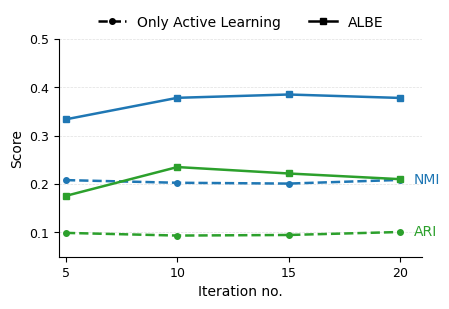

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

# =========================
# 1. 读入 4 个 epoch 的 panel_B 结果
# =========================

EPOCHS = [5, 10, 15, 20]
root_path = r'D:\code\DeepView\deepview\calculate_results\pape_results'
base_csv = "panel_B_metrics.csv"

def load_epoch(rootpath, epochidfile, epoch, base_csv):
    df = pd.read_csv(os.path.join(rootpath, epochidfile, base_csv))
    df["Epoch"] = epoch
    return df

dfs = [
    load_epoch(root_path, 'fig_supcon_vs_ce_ep5', 5, base_csv),
    load_epoch(root_path, 'fig_supcon_vs_ce_ep10', 10, base_csv),
    load_epoch(root_path, 'fig_supcon_vs_ce_ep15', 15, base_csv),
    load_epoch(root_path, 'fig_supcon_vs_ce_ep20', 20, base_csv),
]
metrics_all = pd.concat(dfs, ignore_index=True)

# 只保留需要展示的三个 metric
METRIC_ORDER = [
    "NMI (9-class)",
    "ARI (9-class)",
    # "Unknown F1",
]
METHODS = ["Only Active Learning", "ALBE"]

metric_colors = {
    "NMI (9-class)": "#1f77b4",   # 蓝
    "ARI (9-class)": "#2ca02c",   # 绿
    # "Unknown F1":    "#d62728",   # 红
}

metric_short_label = {
    "NMI (9-class)": "NMI",
    "ARI (9-class)": "ARI",
    # "Unknown F1":    "Unknown F1",
}

linestyles = {
    "Only Active Learning": "--",
    "ALBE": "-",
}
markers = {
    "Only Active Learning": "o",  # Only Active Learning：圆点
    "ALBE": "s",                  # ALBE：方块
}

# =========================
# 2. 绘图：一张图展示 NMI / ARI / Unknown F1
# =========================

fig, ax = plt.subplots(figsize=(4.6, 3.2))

all_vals = []

for metric in METRIC_ORDER:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        # METHODS 中的名字映射到 csv 里的列名
        if method == "Only Active Learning":
            method_key = "CE-only"
        else:
            method_key = "CE+SupCon"

        y = df_m[method_key].values
        all_vals.append(y)

        ax.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

# 设置 y 轴范围和刻度
all_vals = np.concatenate(all_vals)
vmin, vmax = all_vals.min(), all_vals.max()
pad = (vmax - vmin) * 0.15 if vmax > vmin else 0.05
ax.set_ylim(max(0.0, vmin - pad), 0.5)
# ax.set_ylim(max(0.0, vmin - pad), min(0.5, vmax + pad))
# ax.set_yticks(np.linspace(0.0, 1.0, 6))

# x 轴范围留一点空间给右侧文字
ax.set_xlim(EPOCHS[0] - 0.3, EPOCHS[-1] + 1.0)
ax.set_xticks(EPOCHS)

# 坐标轴 & 网格 & 标签
ax.set_xlabel("Iteration no.", fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：B
ax.text(
    -0.16, 1.04, "",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# =========================
# 3. 右侧直接标注每条 metric（以 Only Active Learning 的最后一帧为基准）
# =========================

x_text = EPOCHS[-1] + 0.6

for metric in METRIC_ORDER:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == EPOCHS[-1])
    ]

    y_oa   = df_last["CE-only"].values
    y_albe = df_last["CE+SupCon"].values

    # ✅ 优先用 Only Active Learning（CE-only），如果是 NaN 再退回 ALBE（CE+SupCon）
    if len(y_oa) > 0 and not np.isnan(y_oa[0]):
        y_text = float(y_oa[0])
    elif len(y_albe) > 0 and not np.isnan(y_albe[0]):
        y_text = float(y_albe[0])
    else:
        continue

    ax.text(
        x_text,
        y_text,
        metric_short_label[metric],
        color=metric_colors[metric],
        fontsize=10,
        va="center",
    )

# =========================
# 4. Method 图例（只解释线型 + marker）
# =========================

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyles[m],
        marker=markers[m],
        linewidth=1.8,
        markersize=4.0,
        label=m,
    )
    for m in METHODS
]

ax.legend(
    handles=method_handles,
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    loc="lower center",           # 以图例底边为参照
    bbox_to_anchor=(0.5, 1.02),   # 放在坐标轴正上方、居中
    ncol=2,                       # 横向排成一行
    borderaxespad=0.0,
)

fig.tight_layout()
# plt.show()

fig.savefig(
    "f3.png",          # 或 "figure.tiff"
    dpi=600,               # 分辨率，300 以上适合印刷
    bbox_inches="tight",
    # pad_inches=0.02
)


# pannel A

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. 读入各个 epoch 的 panel A 结果
# =========================

# 你实际有几个 epoch 就写几个，这里按和 panel B 一致的 4 个
epoch_folders = {
    5:  "fig_supcon_vs_ce_ep5",
    10: "fig_supcon_vs_ce_ep10",
    15: "fig_supcon_vs_ce_ep15",
    20: "fig_supcon_vs_ce_ep20",
}

root_path = r"D:\code\DeepView\deepview\calculate_results\pape_results"
base_csv = "panelA_demo.csv"   # 每个目录里的文件名

def load_epoch(rootpath, subdir, epoch, filename):
    df = pd.read_csv(os.path.join(rootpath, subdir, filename))
    df["Epoch"] = epoch
    return df

dfs = [
    load_epoch(root_path, subdir, ep, base_csv)
    for ep, subdir in epoch_folders.items()
]
metrics_all = pd.concat(dfs, ignore_index=True)
# metrics_all

In [19]:
metric_short_label

{'nmi_true': 'NMI (rest)',
 'ari_true': 'ARI (rest)',
 'CH (scaled)': 'CH',
 'hopkins': 'Hopkins'}

['silhouette', '1/DB', 'CH (scaled)', 'hopkins']


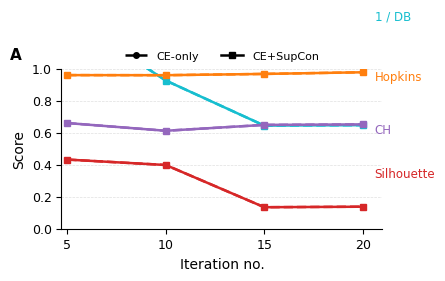

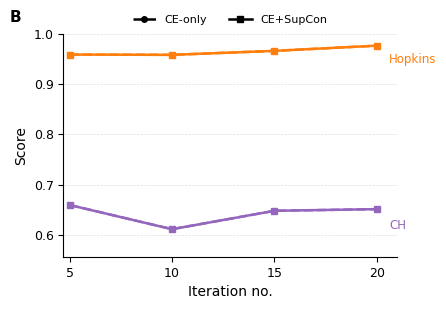

In [17]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# =========================
# 1. 读入 metrics_all
# =========================

# # 如果已经在别处构造好了 DataFrame，直接注释掉这两行即可
# metrics_all = pd.read_csv(r"D:\code\DeepView\deepview\calculate_results\pape_results\panelA_metrics_all.csv")

EPOCHS = [5, 10, 15, 20]
# METHODS = ["Only Active Learning", "ALBE"]

# metrics_all 预期列名：
# ["Metric", "CE_only", "SupCon", "epoch"]
# 如果还有 idx 列无所谓，不影响下面逻辑

# =========================
# 通用设定：颜色 / 线型 / 点型
# =========================

metric_colors = {
    "nmi_true":     "#1f77b4",  # 蓝
    "ari_true":     "#2ca02c",  # 绿
    "CH (scaled)":  "#9467bd",  # 紫
    "hopkins":      "#ff7f0e",  # 橙
    "silhouette":   "#d62728",  # 红
    "1/DB":         "#17becf",  # 青色 / 蓝绿
}


metric_short_label = {
    "nmi_true":     "NMI (rest)",
    "ari_true":     "ARI (rest)",
    "CH (scaled)":  "CH",
    "hopkins":      "Hopkins",
    "silhouette":   "Silhouette",
    "1/DB":         "1 / DB",
}



# 方法线型 / marker / 文案
linestyles = {
    "CE-only": "--",
    "CE+SupCon": "-",
}
markers = {
    "CE-only": "o",   # Only Active Learning：圆点
    "CE+SupCon": "s", # ALBE：方块
}
method_labels = {
    "CE-only": "Only Active Learning",
    "CE+SupCon": "ALBE",
}

def method_to_col(method_name: str) -> str:
    """方法名映射到 DataFrame 列名"""
    return "CE-only" if method_name == "Only Active Learning" else "CE+SupCon"


# =========================
# 2. 图1：nmi_true / ari_true vs epoch
# =========================
METRIC_ORDER = [
    "silhouette",
    "1/DB",
    "CH (scaled)",
    "hopkins",
]
METHODS = ["CE-only", "CE+SupCon"]

# 只保留在数据中确实存在、且不全是 NaN 的 metric
valid_metrics = []
for m in METRIC_ORDER:
    sub = metrics_all[metrics_all["Metric"] == m][METHODS]
    if not sub.dropna(how="all").empty:
        valid_metrics.append(m)
METRIC_ORDER_1 = valid_metrics
print(METRIC_ORDER_1)
# METRIC_ORDER_1 = ["nmi_true", "ari_true"]

fig1, ax1 = plt.subplots(figsize=(4.6, 3.2))

all_vals = []

for metric in METRIC_ORDER_1:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        col = method_to_col(method)
        y = df_m[col].values
        all_vals.append(y)

        ax1.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

# y 轴范围
all_vals = np.concatenate(all_vals)
vmin, vmax = all_vals.min(), all_vals.max()
pad = (vmax - vmin) * 0.15 if vmax > vmin else 0.05
ax1.set_ylim(max(0.0, vmin - pad), min(1.0, vmax + pad))

# 根据数值量级，你也可以改成自适应刻度，这里先简单设 0–1
ax1.set_yticks(np.linspace(0.0, 1.0, 6))

# x 轴
ax1.set_xlim(EPOCHS[0] - 0.3, EPOCHS[-1] + 1.0)
ax1.set_xticks(EPOCHS)

ax1.set_xlabel("Iteration no.", fontsize=10)
ax1.set_ylabel("Score", fontsize=10)
ax1.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：A
ax1.text(
    -0.16, 1.04, "A",
    transform=ax1.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# 右侧直接标注每条 metric（以 CE_only 的最后一帧为基准，不是就 fallback 到 SupCon）
x_text = EPOCHS[-1] + 0.6

for metric in METRIC_ORDER_1:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == EPOCHS[-1])
    ]

    y_oa   = df_last["CE-only"].values
    y_albe = df_last["CE+SupCon"].values

    if len(y_oa) > 0 and not np.isnan(y_oa[0]):
        y_text = float(y_oa[0])
    elif len(y_albe) > 0 and not np.isnan(y_albe[0]):
        y_text = float(y_albe[0])
    else:
        continue

    ax1.text(
        x_text,
        y_text,
        metric_short_label[metric],
        color=metric_colors[metric],
        fontsize=8.5,
        va="center",
    )

# Method 图例（线型 + marker）
method_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyles[m],
        marker=markers[m],
        linewidth=1.8,
        markersize=4.0,
        label=m,
    )
    for m in METHODS
]

ax1.legend(
    handles=method_handles,
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    borderaxespad=0.0,
)

fig1.tight_layout()
plt.show()


# =========================
# 3. 图2：CH (scaled) / hopkins vs epoch
# =========================

METRIC_ORDER_2 = ["CH (scaled)", "hopkins"]

fig2, ax2 = plt.subplots(figsize=(4.6, 3.2))

all_vals2 = []

for metric in METRIC_ORDER_2:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        col = method_to_col(method)
        y = df_m[col].values
        all_vals2.append(y)

        ax2.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

all_vals2 = np.concatenate(all_vals2)
vmin2, vmax2 = all_vals2.min(), all_vals2.max()
pad2 = (vmax2 - vmin2) * 0.15 if vmax2 > vmin2 else 0.02
ax2.set_ylim(vmin2 - pad2, min(1.0, vmax2 + pad2))

# 这里数值都在 0.6–1 之间，你可以根据需要自定义刻度
ax2.set_xticks(EPOCHS)
ax2.set_xlim(EPOCHS[0] - 0.3, EPOCHS[-1] + 1.0)

ax2.set_xlabel("Iteration no.", fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：B
ax2.text(
    -0.16, 1.04, "B",
    transform=ax2.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# 右侧文字标注
x_text2 = EPOCHS[-1] + 0.6

for metric in METRIC_ORDER_2:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == EPOCHS[-1])
    ]

    y_oa   = df_last["CE-only"].values
    y_albe = df_last["CE+SupCon"].values

    if len(y_oa) > 0 and not np.isnan(y_oa[0]):
        y_text = float(y_oa[0])
    elif len(y_albe) > 0 and not np.isnan(y_albe[0]):
        y_text = float(y_albe[0])
    else:
        continue

    ax2.text(
        x_text2,
        y_text,
        metric_short_label[metric],
        color=metric_colors[metric],
        fontsize=8.5,
        va="center",
    )

# 同样的 method 图例
ax2.legend(
    handles=method_handles,
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    borderaxespad=0.0,
)

fig2.tight_layout()
plt.show()


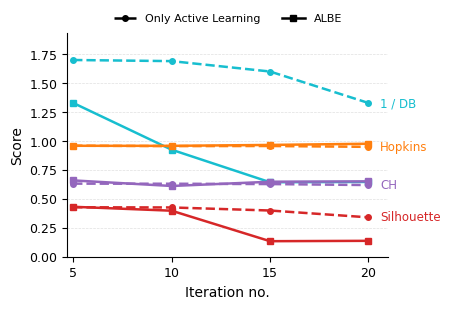

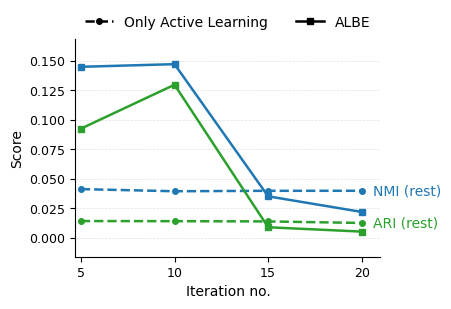

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. 读入 metrics_all
# =========================

# 如果已经在别处构造好了 DataFrame，就注释掉这一行
# metrics_all = pd.read_csv(r"D:\code\DeepView\deepview\calculate_results\pape_results\panelA_metrics_all.csv")

EPOCHS = [5, 10, 15, 20]

# 预期列名：
# ["idx", "Metric", "CE-only", "CE+SupCon", "Epoch"]

# =========================
# 通用设定：颜色 / 线型 / 点型
# =========================

metric_colors = {
    "nmi_true":     "#1f77b4",  # 蓝
    "ari_true":     "#2ca02c",  # 绿
    "CH (scaled)":  "#9467bd",  # 紫
    "hopkins":      "#ff7f0e",  # 橙
    "silhouette":   "#d62728",  # 红
    "1/DB":         "#17becf",  # 青色
}

metric_short_label = {
    "nmi_true":     "NMI (rest)",
    "ari_true":     "ARI (rest)",
    "CH (scaled)":  "CH",
    "hopkins":      "Hopkins",
    "silhouette":   "Silhouette",
    "1/DB":         "1 / DB",
}

# 方法线型 / marker / 文案
METHODS = ["CE-only", "CE+SupCon"]

linestyles = {
    "CE-only": "--",
    "CE+SupCon": "-",
}
markers = {
    "CE-only": "o",   # baseline：圆点
    "CE+SupCon": "s", # ALBE：方块
}
# method_labels = {
#     "CE-only": "CE-only",
#     "CE+SupCon": "CE+SupCon",
# }
method_labels = {
    "CE-only": "Only Active Learning",
    "CE+SupCon": "ALBE",
}

def method_to_col(method_name: str) -> str:
    """现在列名就等于方法名，直接返回即可"""
    return method_name


# =========================
# 2. 图 A：silhouette / 1/DB / CH / hopkins vs epoch
# =========================

METRIC_ORDER_1 = [
    "silhouette",
    "1/DB",
    "CH (scaled)",
    "hopkins",
]

# 只保留在数据中确实存在、且不全是 NaN 的 metric（防守式写法）
valid_metrics = []
for m in METRIC_ORDER_1:
    sub = metrics_all[metrics_all["Metric"] == m][METHODS]
    if not sub.dropna(how="all").empty:
        valid_metrics.append(m)
METRIC_ORDER_1 = valid_metrics

fig1, ax1 = plt.subplots(figsize=(4.6, 3.2))
all_vals = []

for metric in METRIC_ORDER_1:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        col = method_to_col(method)
        y = df_m[col].values
        all_vals.append(y)

        ax1.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

# y 轴范围
all_vals = np.concatenate(all_vals)
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
pad = (vmax - vmin) * 0.15 if vmax > vmin else 0.05
ax1.set_ylim(max(0.0, vmin - pad), max(1.0, vmax + pad))

# x 轴
ax1.set_xlim(EPOCHS[0] - 0.3, EPOCHS[-1] + 1.0)
ax1.set_xticks(EPOCHS)

ax1.set_xlabel("Iteration no.", fontsize=10)
ax1.set_ylabel("Score", fontsize=10)
ax1.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：A
ax1.text(
    -0.16, 1.04, "",
    transform=ax1.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# 右侧文字标注（按 CE-only 最后一帧放 label，缺失则用 CE+SupCon）
x_text = EPOCHS[-1] + 0.6

for metric in METRIC_ORDER_1:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == EPOCHS[-1])
    ]

    y_oa   = df_last["CE-only"].values
    y_albe = df_last["CE+SupCon"].values

    if len(y_oa) > 0 and not np.isnan(y_oa[0]):
        y_text = float(y_oa[0])
    elif len(y_albe) > 0 and not np.isnan(y_albe[0]):
        y_text = float(y_albe[0])
    else:
        continue

    ax1.text(
        x_text,
        y_text,
        metric_short_label[metric],
        color=metric_colors[metric],
        fontsize=8.5,
        va="center",
    )

# Method 图例（线型 + marker）
method_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyles[m],
        marker=markers[m],
        linewidth=1.8,
        markersize=4.0,
        label=method_labels[m],
    )
    for m in METHODS
]

ax1.legend(
    handles=method_handles,
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    borderaxespad=0.0,
)

fig1.tight_layout()
# plt.show()
fig1.savefig(
    "f1.png",          # 或 "figure.svg", "figure.eps"
    bbox_inches="tight",   # 去掉多余白边
    # pad_inches=0.02        # 适当留一点空白（可选）
)

# =========================
# 3. 图 B：CH (scaled) / hopkins vs epoch（如果想单独放一张）
# =========================

METRIC_ORDER_2 = ["nmi_true", "ari_true"]

# metric_short_label = {
#     "nmi_true":     "NMI (rest)",
#     "ari_true":     "ARI (rest)",
#     "CH (scaled)":  "CH",
#     "hopkins":      "Hopkins",
#     "silhouette":   "Silhouette",
#     "1/DB":         "1 / DB",
# }
fig2, ax2 = plt.subplots(figsize=(4.6, 3.2))
all_vals2 = []

for metric in METRIC_ORDER_2:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        col = method_to_col(method)
        y = df_m[col].values
        all_vals2.append(y)

        ax2.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

all_vals2 = np.concatenate(all_vals2)
vmin2, vmax2 = np.nanmin(all_vals2), np.nanmax(all_vals2)
pad2 = (vmax2 - vmin2) * 0.15 if vmax2 > vmin2 else 0.02
ax2.set_ylim(vmin2 - pad2, min(1.0, vmax2 + pad2))

ax2.set_xticks(EPOCHS)
ax2.set_xlim(EPOCHS[0] - 0.3, EPOCHS[-1] + 1.0)

ax2.set_xlabel("Iteration no.", fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：B
ax2.text(
    -0.16, 1.04, "",
    transform=ax2.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# 右侧文字标注
x_text2 = EPOCHS[-1] + 0.6

for metric in METRIC_ORDER_2:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == EPOCHS[-1])
    ]

    y_oa   = df_last["CE-only"].values
    y_albe = df_last["CE+SupCon"].values

    if len(y_oa) > 0 and not np.isnan(y_oa[0]):
        y_text = float(y_oa[0])
    elif len(y_albe) > 0 and not np.isnan(y_albe[0]):
        y_text = float(y_albe[0])
    else:
        continue

    ax2.text(
        x_text2,
        y_text,
        metric_short_label[metric],
        color=metric_colors[metric],
        fontsize=10,
        va="center",
    )

ax2.legend(
    handles=method_handles,
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    borderaxespad=0.0,
)

fig2.tight_layout()
# plt.show()

fig2.savefig(
    "f2.png",          # 或 "figure.svg", "figure.eps"
    bbox_inches="tight",   # 去掉多余白边
    # pad_inches=0.02        # 适当留一点空白（可选）
)

In [10]:
markers

{'CE-only': 'o', 'CE+SupCon': 's'}

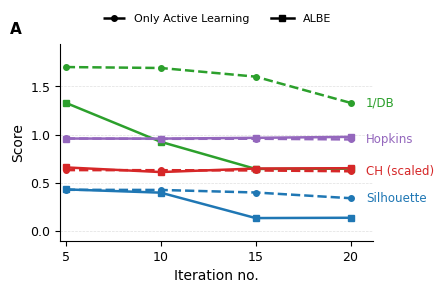

In [3]:
# 旧版本，有问题

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. 读入各个 epoch 的 panel A 结果
# =========================

# 你实际有几个 epoch 就写几个，这里按和 panel B 一致的 4 个
epoch_folders = {
    5:  "fig_supcon_vs_ce_ep5",
    10: "fig_supcon_vs_ce_ep10",
    15: "fig_supcon_vs_ce_ep15",
    20: "fig_supcon_vs_ce_ep20",
}

root_path = r"D:\code\DeepView\deepview\calculate_results\pape_results"
base_csv = "panelA_demo.csv"   # 每个目录里的文件名

def load_epoch(rootpath, subdir, epoch, filename):
    df = pd.read_csv(os.path.join(rootpath, subdir, filename))
    df["Epoch"] = epoch
    return df

dfs = [
    load_epoch(root_path, subdir, ep, base_csv)
    for ep, subdir in epoch_folders.items()
]
metrics_all = pd.concat(dfs, ignore_index=True)

# =========================
# 2. 选择要画的 metrics
# =========================
# 你给的 demo 文件包含：
#   nmi_true, ari_true, silhouette, 1/DB, CH (scaled), hopkins
# 下面默认画 4 个 clusterability 指标，避免太挤；
# 如果以后 nmi_true/ari_true 有值，也可以加进去。
METRIC_ORDER = [
    "silhouette",
    "1/DB",
    "CH (scaled)",
    "hopkins",
]
METHODS = ["CE-only", "CE+SupCon"]

# 只保留在数据中确实存在、且不全是 NaN 的 metric
valid_metrics = []
for m in METRIC_ORDER:
    sub = metrics_all[metrics_all["Metric"] == m][METHODS]
    if not sub.dropna(how="all").empty:
        valid_metrics.append(m)
METRIC_ORDER = valid_metrics

# 为每个 metric 设定颜色和短标签
metric_colors = {
    "silhouette": "#1f77b4",   # 蓝
    "1/DB": "#2ca02c",         # 绿
    "CH (scaled)": "#d62728",  # 红
    "hopkins": "#9467bd",      # 紫
}
metric_short_label = {
    "silhouette": "Silhouette",
    "1/DB": "1/DB",
    "CH (scaled)": "CH (scaled)",
    "hopkins": "Hopkins",
}

# 方法线型 / marker / 文案
linestyles = {
    "CE-only": "--",
    "CE+SupCon": "-",
}
markers = {
    "CE-only": "o",   # Only Active Learning：圆点
    "CE+SupCon": "s", # ALBE：方块
}
method_labels = {
    "CE-only": "Only Active Learning",
    "CE+SupCon": "ALBE",
}

# =========================
# 3. 绘图
# =========================

fig, ax = plt.subplots(figsize=(4.6, 3.2))

all_vals = []

for metric in METRIC_ORDER:
    df_m = (
        metrics_all[metrics_all["Metric"] == metric]
        .sort_values("Epoch")
    )
    epochs = df_m["Epoch"].values

    for method in METHODS:
        y = df_m[method].values
        all_vals.append(y[~np.isnan(y)])

        ax.plot(
            epochs,
            y,
            color=metric_colors[metric],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=1.8,
            markersize=4.0,
        )

# y 轴范围：根据数据自动 + 一点 padding
all_vals_flat = np.concatenate(all_vals) if len(all_vals) > 0 else np.array([0.0, 1.0])
vmin, vmax = float(all_vals_flat.min()), float(all_vals_flat.max())
pad = (vmax - vmin) * 0.15 if vmax > vmin else 0.05
ax.set_ylim(vmin - pad, vmax + pad)

# x 轴范围多留一点空间给右边文字
epochs_sorted = sorted(epoch_folders.keys())
ax.set_xlim(epochs_sorted[0] - 0.3, epochs_sorted[-1] + 1.2)
ax.set_xticks(epochs_sorted)

# 轴标签和样式
ax.set_xlabel("Iteration no.", fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.tick_params(axis="both", labelsize=9)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Panel 标记：A
ax.text(
    -0.16, 1.04, "A",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom",
)

# =========================
# 4. 右侧直接标注每个 metric（用 SupCon 最后一个 epoch 的值）
# =========================

x_text = epochs_sorted[-1] + 0.8

for metric in METRIC_ORDER:
    df_last = metrics_all[
        (metrics_all["Metric"] == metric)
        & (metrics_all["Epoch"] == epochs_sorted[-1])
    ]

    y_sup = df_last["CE+SupCon"].values
    y_ce = df_last["CE-only"].values

    # ✅ 优先用 Only Active Learning（CE-only），如果是 NaN 再退回 ALBE（CE+SupCon）
    if len(y_ce) > 0 and not np.isnan(y_ce[0]):
        y_text = float(y_ce[0])
    elif len(y_sup) > 0 and not np.isnan(y_sup[0]):
        y_text = float(y_sup[0])
    else:
        continue  # 如果两个都是 NaN，就跳过

    ax.text(
        x_text,
        y_text,
        metric_short_label.get(metric, metric),
        color=metric_colors[metric],
        fontsize=8.5,
        va="center",
    )

# =========================
# 5. Method 图例：横向放在图正上方
# =========================

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyles[m],
        marker=markers[m],
        linewidth=1.8,
        markersize=4.0,
        label=method_labels[m],  # 使用新的名字
    )
    for m in METHODS
]

ax.legend(
    handles=method_handles,
    # title="Method",
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.08),  # 图上方居中
    ncol=2,
    borderaxespad=0.0,
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# 展示四个sub behavior的统计特征

In [19]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\turtle\acc_gyr_dpt_data.npz'

[PanelA] Loaded 800 windows from: synthetic_demo
              count      mean       std       min       25%       50%  \
sub_behavior                                                            
sub-1         200.0  2.407627  0.612150  0.738268  2.045762  2.408482   
sub-2         200.0  1.554051  0.578343  0.000000  1.136334  1.567133   
sub-3         200.0  2.729251  0.825581  0.362388  2.108723  2.763993   
sub-4         200.0  3.081638  0.807034  0.891666  2.578912  3.044612   

                   75%       max  
sub_behavior                      
sub-1         2.843444  4.071330  
sub-2         1.914419  2.954638  
sub-3         3.253703  5.183237  
sub-4         3.631210  5.125845  
[PanelA] Saved figure to: D:\code\DeepView\deepview\calculate_results\pape_results\panelA_magmean_subbehaviours.png


In [ ]:
# -*- coding: utf-8 -*-
"""
ACC mag.mean (mean sensor-vector norm) violin+box plot with Nature Methods-style
pairwise p-value bracket layout matching the reference:

Order / layout (4 groups => 6 comparisons), stacked bottom->top:
(1,2), (1,3), (1,4), (2,3), (2,4), (3,4)

Also forces y-axis range to [0, 6] as requested.

Input: acc_gyr_dpt_data.npz (keys: data, label)
- data: (N, 7, T) where channels are [acc(3), gyr(3), depth(1)]
- label: (N, T) or (N,)

Output:
- fig1_panelA_acc_magmean_rest4_layout.png
"""

import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import mannwhitneyu
except Exception:
    mannwhitneyu = None


# =============================
# Configuration
# =============================
NPZ_PATH = Path(os.environ.get(
    "PANEL_A_NPZ",
    r"D:\code\DeepView\deepview\calculate_results\data\turtle\acc_gyr_dpt_data.npz"
))
OUT_DIR = Path(os.environ.get("OUT_DIR", str(NPZ_PATH.parent)))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# palette from your legend
PALETTE = ["#5470C6", "#FB96FD", "#B6E880", "#FECB52"]

# target size ~483x613 px
FIG_W_PX, FIG_H_PX = 510, 683
# FIG_W_PX, FIG_H_PX = 483, 613
DPI = 300
FIGSIZE_INCH = (FIG_W_PX / DPI, FIG_H_PX / DPI)

# 4 sub-rest classes
REST_LABEL_IDS = [0, 1, 2, 3]
REST_LABEL_ID_TO_NAME: Dict[int, str] = {
    0: "General\nresting",
    1: "Resting\nactive",
    2: "Resting\nin flow",
    3: "Resting\nwatching",
}

ACC_IDX = [0, 1, 2]


# =============================
# Helpers
# =============================
def majority_vote_labels(label: np.ndarray) -> np.ndarray:
    if label.ndim == 1:
        return label.astype(int)
    lab = label.astype(int)
    minv = int(lab.min())
    if minv < 0:
        lab = lab - minv
    maxv = int(lab.max())
    out = np.empty((lab.shape[0],), dtype=int)
    for i in range(lab.shape[0]):
        out[i] = np.bincount(lab[i], minlength=maxv + 1).argmax()
    if minv < 0:
        out = out + minv
    return out


def mean_vector_norm(data_ct: np.ndarray, channel_idx: List[int]) -> np.ndarray:
    x = data_ct[:, channel_idx, :]       # (N,k,T)
    xtk = np.transpose(x, (0, 2, 1))     # (N,T,k)
    mag = np.linalg.norm(xtk, axis=2)    # (N,T)
    return mag.mean(axis=1)              # (N,)


def p_to_stars(p: float) -> str:
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def mwu_p(a: np.ndarray, b: np.ndarray) -> float:
    if mannwhitneyu is None:
        return float("nan")
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return float(p)


def add_bracket(ax, x1, x2, y, h, text, lw=0.9, fs=8.5):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y -0.8* h , text,
            ha="center", va="bottom", fontsize=fs)


# =============================
# Plot
# =============================
def plot_acc(groups: List[np.ndarray], xlabels: List[str], out_png: Path):
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 10,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 1.0,
    })

    fig, ax = plt.subplots(figsize=FIGSIZE_INCH, dpi=DPI)
    pos = np.arange(1, 5)

    # violin
    vp = ax.violinplot(groups, positions=pos, widths=0.78,
                       showmeans=False, showmedians=False, showextrema=False)
    for i, body in enumerate(vp["bodies"]):
        body.set_facecolor(PALETTE[i])
        body.set_edgecolor("none")
        body.set_alpha(0.30)

    # box
    bp = ax.boxplot(groups, positions=pos, widths=0.20,
                    patch_artist=True, showfliers=False)
    for box in bp["boxes"]:
        box.set_facecolor("white")
        box.set_edgecolor("black")
        box.set_linewidth(1.0)
    for elem in ["whiskers", "caps", "medians"]:
        for artist in bp[elem]:
            artist.set_color("black")
            artist.set_linewidth(1.0)

    # axes
    ax.set_xticks(pos)
    ax.set_xticklabels(xlabels, rotation=60, ha="center", linespacing=0.9)
    ax.set_ylabel("acc mag.mean")

    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.28)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Force y-axis range as requested
    ax.set_ylim(0, 6)

    # ----- Bracket layout: match the reference order -----
    # pairs in 0-based indices corresponding to positions 1..4
    pair_order = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
    # Fixed y-levels within [0,6] to mimic stacked layout without overlap
    # (bottom -> top)
    y_levels = np.array([4.55, 4.85, 5.15, 5.45, 5.75, 6.05])-0.4
    h = 0.12

    for (i, j), y in zip(pair_order, y_levels):
        p = mwu_p(groups[i], groups[j])
        stars = p_to_stars(p) if np.isfinite(p) else "n/a"
        add_bracket(ax, pos[i], pos[j], y, h, stars)

    fig.tight_layout(pad=0.6)
    fig.savefig(out_png, transparent=True)
    plt.close(fig)


def main():
    if not NPZ_PATH.exists():
        raise FileNotFoundError(f"Cannot find NPZ: {NPZ_PATH.resolve()}")

    z = np.load(NPZ_PATH, allow_pickle=True)
    if "data" not in z.files or "label" not in z.files:
        raise KeyError(f"NPZ must contain keys ['data','label'], got {z.files}")

    data = np.asarray(z["data"])
    label = np.asarray(z["label"])
    win_label = majority_vote_labels(label)

    keep = np.isin(win_label, np.array(REST_LABEL_IDS))
    if keep.sum() == 0:
        raise RuntimeError("No windows match REST_LABEL_IDS; please edit REST_LABEL_IDS.")

    data = data[keep]
    win_label = win_label[keep]

    acc_mag = mean_vector_norm(data, ACC_IDX)

    groups = [acc_mag[win_label == i] for i in REST_LABEL_IDS]
    xlabels = [REST_LABEL_ID_TO_NAME[i] for i in REST_LABEL_IDS]

    out_png = OUT_DIR / "fig1_panelA_acc_magmean_rest4_layout.png"
    plot_acc(groups, xlabels, out_png)
    print("[OK] Saved:", out_png.resolve())


if __name__ == "__main__":
    main()
